In [1]:
library(ggplot2)
library(GenomicRanges)
library(rtracklayer)
library(IRanges)
library(S4Vectors)
library(dplyr)
library(GenomeInfoDb)
library(stringr)
library(DESeq2)
library(ggpubr)

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb


Attaching package: ‘dplyr’


The following 

# Funcion for gene score

In [ ]:
calculateBulkGeneScores <- function(
  genes,
  atac_file,
  file_type = "bigwig",
  geneUpstream = 5000,
  geneDownstream = 0,
  extendUpstream = 100000,  # Maximum upstream extension for signal search
  extendDownstream = 100000, # Maximum downstream extension for signal search
  useGeneBoundaries = TRUE,  # Respect boundaries with neighboring genes
  geneScaleFactor = 1,      # Scaling factor by gene size
  excludeChr = c("chrY", "chrM"),
  normalization_method = "auto",  # "none", "RPM", "quantile", "auto"
  total_reads = NULL,  # Total reads/fragments in the sample (for RPM normalization)
  verbose = TRUE
) {
  
  # Validate input
  if (!file.exists(atac_file)) {
    stop("ATAC file does not exist!")
  }
  
  if (!inherits(genes, "GRanges")) {
    stop("genes must be a GRanges object!")
  }
  
  if (!any(colnames(mcols(genes)) == "symbol")) {
    stop("No symbol column in genes! A column named symbol is expected.")
  }
  
  # Read BigWig file
  if (verbose) message("Loading BigWig file...")
  bw <- rtracklayer::BigWigFile(atac_file)
  
  # Get seqinfo from the BigWig to avoid warnings
  bw_seqinfo <- seqinfo(bw)
  
  # Filter genes by excluded chromosomes and chromosomes present in the BigWig
  genes <- genes[!seqnames(genes) %in% excludeChr]
  genes <- genes[!is.na(mcols(genes)$symbol)]
  
  # Keep only chromosomes that exist in the BigWig
  valid_chrs <- intersect(as.character(unique(seqnames(genes))), seqnames(bw_seqinfo))
  genes <- genes[as.character(seqnames(genes)) %in% valid_chrs]
  
  if (length(genes) == 0) {
    stop("No genes left after filtering! Check chromosome names match between genes and BigWig file.")
  }
  
  if (verbose) message(paste0("Processing ", length(genes), " genes..."))
  
  # Store original gene body positions
  # TSS is the transcription start site (5' end of the gene)
  # TTS is the transcription termination site (3' end of the gene)
  genes$geneTSS <- ifelse(as.character(strand(genes)) == "-", 
                          end(genes),    # On the - strand, TSS is at the end
                          start(genes))  # On the + strand, TSS is at the start
  
  genes$geneTTS <- ifelse(as.character(strand(genes)) == "-", 
                          start(genes),  # On the - strand, TTS is at the start
                          end(genes))    # On the + strand, TTS is at the end
  
  genes$geneStart <- start(genes)
  genes$geneEnd <- end(genes)
  
  # Compute weight based on gene size only if geneScaleFactor != 1
  if (geneScaleFactor != 1) {
    gene_widths <- width(genes)
    min_width <- min(gene_widths)
    max_width <- max(gene_widths)
    genes$geneWeight <- 1 + (gene_widths - min_width) / (max_width - min_width) * (geneScaleFactor - 1)
  } else {
    genes$geneWeight <- 1
  }
  
  if (verbose) message("Calculating gene scores from continuous signal...")
  
  # Function to process each gene
  processGene <- function(i) {
    gene <- genes[i]
    
    # Get TSS and TTS positions
    tss_pos <- gene$geneTSS
    tts_pos <- gene$geneTTS
    gene_strand <- as.character(strand(gene))
    
    # Define the plateau region (TSS-5kb to TTS)
    # This is the region with maximum weight
    if (gene_strand == "+") {
      # Positive strand: TSS is left, TTS is right
      plateau_start <- tss_pos - geneUpstream  # TSS - 5kb
      plateau_end <- tts_pos + geneDownstream  # TTS + 0
    } else {
      # Negative strand: TSS is right, TTS is left
      # But we want plateau_start < plateau_end for the calculations
      plateau_start <- tts_pos - geneDownstream  # TTS is on the left
      plateau_end <- tss_pos + geneUpstream      # TSS + 5kb (toward the left in coordinates)
    }
    
    # Ensure plateau_start < plateau_end
    if (plateau_start > plateau_end) {
      temp <- plateau_start
      plateau_start <- plateau_end
      plateau_end <- temp
    }
    
    # Define extended search region
    search_start <- plateau_start - extendUpstream
    search_end <- plateau_end + extendDownstream
    
    # Consider boundaries with neighboring genes if enabled
    if (useGeneBoundaries) {
      chr_genes <- genes[seqnames(genes) == seqnames(gene)]
      chr_genes <- sort(chr_genes)
      gene_idx <- which(chr_genes$symbol == gene$symbol)[1]
      
      # Adjust boundaries considering neighboring genes
      if (gene_idx > 1) {
        prev_gene <- chr_genes[gene_idx - 1]
        # Do not extend beyond the previous gene (leave a 100bp buffer)
        search_start <- max(search_start, end(prev_gene) + 100)
      }
      
      if (gene_idx < length(chr_genes)) {
        next_gene <- chr_genes[gene_idx + 1]
        # Do not extend beyond the next gene
        search_end <- min(search_end, start(next_gene) - 100)
      }
    }
    
    # Ensure we do not go outside the chromosome
    search_start <- max(1, search_start)
    
    # Ensure search_end > search_start
    if (search_end <= search_start) {
      # If genes are too close, use only the plateau region
      search_start <- max(1, plateau_start)
      search_end <- plateau_end
    }
    
    # Ensure a minimum region of at least 1bp
    if (search_end <= search_start) {
      search_end <- search_start + 1
    }
    
    # Create search region
    search_region <- GRanges(
      seqnames = seqnames(gene),
      ranges = IRanges(start = as.integer(search_start), 
                      end = as.integer(search_end))
    )
    
    # Extract BigWig signal
    gene_score <- tryCatch({
      # Import signal as GRanges
      signal_gr <- import(bw, selection = search_region, as = "GRanges")
      
      if (length(signal_gr) > 0) {
        # Compute the center of each signal interval
        signal_positions <- start(signal_gr) + (width(signal_gr) / 2)
        
        # Compute distance to the plateau (TSS-5kb to TTS)
        # Inside plateau: distance = 0
        # Outside plateau: positive distance
        dist_to_plateau <- case_when(
          signal_positions < plateau_start ~ plateau_start - signal_positions,
          signal_positions > plateau_end ~ signal_positions - plateau_end,
          TRUE ~ 0  # Inside plateau
        )
        
        # Apply weighting function
        # Inside plateau: weight = 1 + exp(-1) ≈ 1.368
        # Outside plateau: exponential decay from that value
        max_weight <- 1 + exp(-1)
        weights <- ifelse(dist_to_plateau == 0,
                         max_weight,  # Max weight in plateau
                         exp(-dist_to_plateau / 5000))  # Decay outside plateau
        
        # Apply gene-specific weight based on gene size (if specified)
        weights <- weights * gene$geneWeight
        
        # Compute weighted score
        # Include interval width for correct integration
        weighted_signal <- signal_gr$score * weights * width(signal_gr)
        score <- sum(weighted_signal, na.rm = TRUE)
        
        score
      } else {
        0
      }
      
    }, error = function(e) {
      if (verbose) {
        message(paste0("  Warning: Error processing gene ", gene$symbol, ": ", e$message))
      }
      NA
    })
    
    return(gene_score)
  }
  
  # Process all genes
  if (verbose) message("Processing genes...")
  
  gene_scores <- sapply(seq_along(genes), function(i) {
    if (verbose && i %% 25 == 0) {
      message(paste0("  Processed ", i, " of ", length(genes), " genes"))
    }
    processGene(i)
  })
  
  names(gene_scores) <- mcols(genes)$symbol
  
  # Remove NAs if present
  valid_scores <- !is.na(gene_scores)
  if (sum(!valid_scores) > 0 && verbose) {
    message(paste0("Warning: ", sum(!valid_scores), " genes had errors and were set to NA"))
  }
  
  # Compute total BigWig signal if needed
  if (normalization_method == "auto" || (normalization_method == "RPM" && is.null(total_reads))) {
    if (verbose) message("Calculating total signal in BigWig for normalization...")
    
    # Get all BigWig chromosomes
    bw_chrs <- seqnames(bw_seqinfo)
    bw_chrs <- bw_chrs[!bw_chrs %in% excludeChr]
    
    # Compute total signal sum
    total_signal <- 0
    for (chr in bw_chrs) {
      chr_length <- seqlengths(bw_seqinfo)[chr]
      if (!is.na(chr_length)) {
        chr_region <- GRanges(seqnames = chr,
                             ranges = IRanges(start = 1, end = chr_length))
        tryCatch({
          chr_signal <- import(bw, selection = chr_region, as = "GRanges")
          if (length(chr_signal) > 0) {
            total_signal <- total_signal + sum(chr_signal$score * width(chr_signal), na.rm = TRUE)
          }
        }, error = function(e) {
          if (verbose) message(paste0("  Warning: Could not read ", chr))
        })
      }
    }
    
    if (verbose) message(paste0("  Total signal in BigWig: ", format(total_signal, scientific = TRUE)))
    
    # If total_reads was not provided, use total_signal as a proxy
    if (is.null(total_reads)) {
      total_reads <- total_signal
    }
  }
  
  # Apply normalization based on selected method
  if (normalization_method == "RPM" || normalization_method == "auto") {
    # RPM normalization (Reads Per Million)
    if (!is.null(total_reads) && total_reads > 0) {
      scaling_factor <- 1e6 / total_reads
      gene_scores_rpm <- gene_scores * scaling_factor
      if (verbose) message(paste0("Applied RPM normalization with scaling factor: ", 
                                  format(scaling_factor, scientific = TRUE)))
    } else {
      gene_scores_rpm <- gene_scores
      if (verbose) message("Warning: Could not apply RPM normalization (total_reads = 0 or NULL)")
    }
  } else {
    gene_scores_rpm <- gene_scores
  }
  
  # Additional normalization: Quantile normalization (useful for comparing multiple samples)
  gene_scores_quantile <- rep(NA, length(gene_scores))
  if (sum(valid_scores) > 1 && normalization_method %in% c("quantile", "auto")) {
    # Rank-based quantile normalization
    ranks <- rank(gene_scores[valid_scores], na.last = "keep")
    gene_scores_quantile[valid_scores] <- qnorm(ranks / (sum(valid_scores) + 1))
  }
  names(gene_scores_quantile) <- names(gene_scores)
  
  # 1. Log-transform to reduce outlier effects (apply on RPM)
  gene_scores_log <- log1p(gene_scores_rpm)
  
  # 2. Z-score normalization (on log-RPM)
  gene_scores_zscore <- rep(NA, length(gene_scores))
  if (sum(valid_scores) > 1) {
    gene_scores_zscore[valid_scores] <- scale(gene_scores_log[valid_scores])[, 1]
  }
  names(gene_scores_zscore) <- names(gene_scores)
  
  # 3. Percentile ranks (0-100) based on RPM scores
  gene_scores_percentile <- rep(NA, length(gene_scores))
  if (sum(valid_scores) > 0) {
    gene_scores_percentile[valid_scores] <- rank(gene_scores_rpm[valid_scores]) / sum(valid_scores) * 100
  }
  names(gene_scores_percentile) <- names(gene_scores)
  
  # Create results dataframe
  results_df <- data.frame(
    gene_symbol = mcols(genes)$symbol,
    chromosome = as.character(seqnames(genes)),
    start = start(genes),
    end = end(genes),
    strand = as.character(strand(genes)),
    TSS = genes$geneTSS,
    TTS = genes$geneTTS,
    gene_width = width(genes),
    raw_score = gene_scores,
    rpm_score = gene_scores_rpm,
    log_rpm_score = gene_scores_log,
    z_score = gene_scores_zscore,
    percentile = gene_scores_percentile,
    quantile_norm = gene_scores_quantile,
    stringsAsFactors = FALSE
  )
  
  # Sort by rpm_score descending
  results_df <- results_df[order(results_df$rpm_score, decreasing = TRUE, na.last = TRUE), ]
  
  # Return a list with all information
  result <- list(
    scores = results_df,
    genes = genes,
    parameters = list(
      atac_file = atac_file,
      geneUpstream = geneUpstream,
      geneDownstream = geneDownstream,
      extendUpstream = extendUpstream,
      extendDownstream = extendDownstream,
      useGeneBoundaries = useGeneBoundaries,
      geneScaleFactor = geneScaleFactor,
      plateau_weight = 1 + exp(-1),
      normalization_method = normalization_method,
      total_reads = total_reads
    )
  )
  
  if (verbose) {
    message("Done!")
    message(paste0("\nTop 5 genes by RPM-normalized score:"))
    top5 <- head(results_df[!is.na(results_df$rpm_score), c("gene_symbol", "rpm_score", "percentile")], 5)
    print(top5)
    
    message(paste0("\nBottom 5 genes by RPM-normalized score:"))
    bottom5 <- tail(results_df[!is.na(results_df$rpm_score), c("gene_symbol", "rpm_score", "percentile")], 5)
    print(bottom5)
  }
  
  return(result)
}


In [4]:
convertPeaksToGenes <- function(df1, use_gene_body = TRUE) {
  
  # Remove rows without gene symbols
  df1_clean <- df1[!is.na(df1$nearest_symbol) & df1$nearest_symbol != "", ]
  
  if (use_gene_body) {
    # Remove rows with invalid gene body coordinates
    valid_coords <- !is.na(df1_clean$gene_body_start) & 
                   !is.na(df1_clean$gene_body_end) & 
                   !is.na(df1_clean$gene_body_chr) &
                   df1_clean$gene_body_start > 0 &
                   df1_clean$gene_body_end > df1_clean$gene_body_start
    
    if(sum(valid_coords) == 0) {
      stop("No genes with valid gene body coordinates found")
    }
    
    if(sum(!valid_coords) > 0) {
      message("Removing ", sum(!valid_coords), " genes with invalid gene body coordinates")
      df1_clean <- df1_clean[valid_coords, ]
    }
    
    # Use actual gene body coordinates
    genes_gr <- GRanges(
      seqnames = df1_clean$gene_body_chr,
      ranges = IRanges(start = df1_clean$gene_body_start, 
                      end = df1_clean$gene_body_end),
      strand = df1_clean$gene_body_strand,
      symbol = df1_clean$nearest_symbol,
      entrez_id = df1_clean$nearest_entrez,
      peak_chr = df1_clean$chr,
      peak_start = df1_clean$start,
      peak_end = df1_clean$end,
      distance_to_tss = df1_clean$distance_bp
    )
  } else {
    # Validate peak coordinates
    valid_coords <- !is.na(df1_clean$start) & 
                   !is.na(df1_clean$end) & 
                   !is.na(df1_clean$chr) &
                   df1_clean$start > 0 &
                   df1_clean$end > df1_clean$start
    
    if(sum(valid_coords) == 0) {
      stop("No peaks with valid coordinates found")
    }
    
    if(sum(!valid_coords) > 0) {
      message("Removing ", sum(!valid_coords), " peaks with invalid coordinates")
      df1_clean <- df1_clean[valid_coords, ]
    }
    
    # Use peak coordinates (less recommended for gene scoring)
    genes_gr <- GRanges(
      seqnames = df1_clean$chr,
      ranges = IRanges(start = df1_clean$start, 
                      end = df1_clean$end),
      strand = df1_clean$tss_strand,
      symbol = df1_clean$nearest_symbol,
      entrez_id = df1_clean$nearest_entrez,
      distance_to_tss = df1_clean$distance_bp
    )
  }
  
  # Remove duplicated genes (keep first occurrence)
  genes_gr <- genes_gr[!duplicated(genes_gr$symbol)]
  
  # Final validation of coordinates
  valid_final <- width(genes_gr) > 0 & !is.na(start(genes_gr)) & !is.na(end(genes_gr))
  if(sum(!valid_final) > 0) {
    message("Removing ", sum(!valid_final), " genes with invalid final coordinates")
    genes_gr <- genes_gr[valid_final]
  }
  
  # Sort by chromosome and position
  genes_gr <- sort(genes_gr)
  
  message("Final gene count: ", length(genes_gr))
  
  return(genes_gr)
}

## New code

In [10]:
# List to store all plot_df2 dataframes
all_results <- list()

# =============================================================================
# LT_RESULT_ANNOT - M12
# =============================================================================
df1 <- read.table('/data/peer/sotougl/notebooks2/lt_result_annot.tsv')
genes_from_df1 <- convertPeaksToGenes(df1, use_gene_body = TRUE)
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")

bw <- BigWigFile('/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep1_cutsites.bw')
bw_si <- seqinfo(bw)
seqlevelsStyle(genes_from_df1) <- seqlevelsStyle(bw_si)[1]
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")
drop_me <- grep("_(alt|random|fix)$|^chrUn|\\.[0-9]+$", seqlevels(genes_from_df1), value = TRUE)
if (length(drop_me)) {
  genes_from_df1 <- dropSeqlevels(genes_from_df1, drop_me, pruning.mode = "coarse")
}
common <- intersect(seqlevels(genes_from_df1), seqlevels(bw_si))
genes_from_df1 <- keepSeqlevels(genes_from_df1, common, pruning.mode = "coarse")
seqlengths(genes_from_df1)[common] <- seqlengths(bw_si)[common]

m12_imq_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_imq_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_imq_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_imq_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")

plot_df <- data.frame(m12_imq_1 = m12_imq_1$scores$rpm_score, m12_imq_2 = m12_imq_2$scores$rpm_score, m12_imq_3 = m12_imq_3$scores$rpm_score, m12_imq_4 = m12_imq_4$scores$rpm_score, m12_ctrl_1 = m12_ctrl_1$scores$rpm_score, m12_ctrl_2 = m12_ctrl_2$scores$rpm_score, m12_ctrl_3 = m12_ctrl_3$scores$rpm_score, m12_ctrl_4 = m12_ctrl_4$scores$rpm_score)
rownames(plot_df) = m12_imq_1$genes$symbol

zs <- as.data.frame(t(scale(t(plot_df), center = TRUE, scale = TRUE)))
all_results$lt_m12 <- zs %>%
  tibble::rownames_to_column(var = "gene") %>%
  tidyr::pivot_longer(-gene, names_to = "sample", values_to = "value") %>% 
  mutate(group = case_when(str_detect(sample, "(?i)imq") ~ "IMQ", str_detect(sample, "(?i)ctrl") ~ "Ctrl", TRUE ~ NA_character_), gene = factor(gene, levels = unique(gene)))

Final gene count: 112

Loading BigWig file...

Processing 112 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 112 genes

  Processed 50 of 112 genes

  Processed 75 of 112 genes

  Processed 100 of 112 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 4.017482e+07

Applied RPM normalization with scaling factor: 2.489121e-02

Done!


Top 5 genes by RPM-normalized score:



       gene_symbol rpm_score percentile
Nrg1          Nrg1  545.7923  100.00000
Ptprn2      Ptprn2  420.6993   99.10714
Kank1        Kank1  407.0144   98.21429
Nhsl1        Nhsl1  401.4399   97.32143
Sox5          Sox5  345.5376   96.42857



Bottom 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Mc2r                   Mc2r  6.470111  4.4642857
Rnase2b             Rnase2b  5.852627  3.5714286
Gm4832               Gm4832  5.209371  2.6785714
2900040C04Rik 2900040C04Rik  4.741841  1.7857143
Gm13498             Gm13498  3.557523  0.8928571


Loading BigWig file...

Processing 112 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 112 genes

  Processed 50 of 112 genes

  Processed 75 of 112 genes

  Processed 100 of 112 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 7.13464e+07

Applied RPM normalization with scaling factor: 1.401612e-02

Done!


Top 5 genes by RPM-normalized score:



...

                gene_symbol rpm_score percentile
1810013A23Rik 1810013A23Rik  5.558685  4.4642857
Rnase2b             Rnase2b  5.276993  3.5714286
Gm13498             Gm13498  5.205302  2.6785714
Gm4832               Gm4832  3.939846  1.7857143
2900040C04Rik 2900040C04Rik  3.061313  0.8928571


Loading BigWig file...

Processing 112 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 112 genes

  Processed 50 of 112 genes

  Processed 75 of 112 genes

  Processed 100 of 112 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 3.224733e+07

Applied RPM normalization with scaling factor: 3.101032e-02

Done!


Top 5 genes by RPM-normalized score:



       gene_symbol rpm_score percentile
Nrg1          Nrg1  656.8909  100.00000
Sox5          Sox5  454.1065   99.10714
Ptprn2      Ptprn2  450.9921   98.21429
Kank1        Kank1  346.1263   97.32143
Nhsl1        Nhsl1  342.2721   96.42857



Bottom 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
4930431P22Rik 4930431P22Rik  7.005425  4.4642857
2900040C04Rik 2900040C04Rik  5.477593  3.5714286
Rnase2b             Rnase2b  5.204937  2.6785714
Gm13498             Gm13498  4.828651  1.7857143
Gm4832               Gm4832  2.842031  0.8928571


In [12]:
# =============================================================================
# ST_RESULT - M12
# =============================================================================
df1 <- read.table('/data/peer/sotougl/notebooks2/st_result_annot.tsv')
genes_from_df1 <- convertPeaksToGenes(df1, use_gene_body = TRUE)
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")

# =============================================================================
# ST_RESULT - M12
# =============================================================================
df1 <- read.table('/data/peer/sotougl/notebooks2/st_result_annot.tsv')
genes_from_df1 <- convertPeaksToGenes(df1, use_gene_body = TRUE)
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")

bw <- BigWigFile('/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep1_cutsites.bw')
bw_si <- seqinfo(bw)
seqlevelsStyle(genes_from_df1) <- seqlevelsStyle(bw_si)[1]
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")
drop_me <- grep("_(alt|random|fix)$|^chrUn|\\.[0-9]+$", seqlevels(genes_from_df1), value = TRUE)
if (length(drop_me)) {
  genes_from_df1 <- dropSeqlevels(genes_from_df1, drop_me, pruning.mode = "coarse")
}
common <- intersect(seqlevels(genes_from_df1), seqlevels(bw_si))
genes_from_df1 <- keepSeqlevels(genes_from_df1, common, pruning.mode = "coarse")
seqlengths(genes_from_df1)[common] <- seqlengths(bw_si)[common]

m12_imq_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_imq_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_imq_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_imq_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_IMQ_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
m12_ctrl_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/M12_Ctrl_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")

plot_df <- data.frame(m12_imq_1 = m12_imq_1$scores$rpm_score, m12_imq_2 = m12_imq_2$scores$rpm_score, m12_imq_3 = m12_imq_3$scores$rpm_score, m12_imq_4 = m12_imq_4$scores$rpm_score, m12_ctrl_1 = m12_ctrl_1$scores$rpm_score, m12_ctrl_2 = m12_ctrl_2$scores$rpm_score, m12_ctrl_3 = m12_ctrl_3$scores$rpm_score, m12_ctrl_4 = m12_ctrl_4$scores$rpm_score)
rownames(plot_df) = m12_imq_1$genes$symbol

zs <- as.data.frame(t(scale(t(plot_df), center = TRUE, scale = TRUE)))
all_results$st_m12 <- zs %>%
  tibble::rownames_to_column(var = "gene") %>%
  tidyr::pivot_longer(-gene, names_to = "sample", values_to = "value") %>% 
  mutate(group = case_when(str_detect(sample, "(?i)imq") ~ "IMQ", str_detect(sample, "(?i)ctrl") ~ "Ctrl", TRUE ~ NA_character_), gene = factor(gene, levels = unique(gene)))


Final gene count: 104

Loading BigWig file...

Processing 104 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 104 genes

  Processed 50 of 104 genes

  Processed 75 of 104 genes

  Processed 100 of 104 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 4.017482e+07

Applied RPM normalization with scaling factor: 2.489121e-02

Done!


Top 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Macrod2             Macrod2  997.7182  100.00000
Efna5                 Efna5  622.5028   99.03846
Chd9                   Chd9  396.4975   98.07692
Rbms3                 Rbms3  370.1049   97.11538
1600002D24Rik 1600002D24Rik  352.0828   96.15385



Bottom 5 genes by RPM-normalized score:



                gene_symbol    rpm_score percentile
Cd209c               Cd209c 2.928143e+00  4.8076923
4930433B08Rik 4930433B08Rik 2.879990e+00  3.8461538
Vmn1r223           Vmn1r223 9.786816e-01  2.8846154
Gm10220             Gm10220 1.021445e-01  1.9230769
Mir21a               Mir21a 5.300707e-08  0.9615385


Loading BigWig file...

Processing 104 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 104 genes

  Processed 50 of 104 genes

  Processed 75 of 104 genes

  Processed 100 of 104 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 7.13464e+07

Applied RPM normalization with scaling factor: 1.401612e-02

Done!


Top 5 genes by RPM-normalized score:



...

         gene_symbol    rpm_score percentile
Vmp1            Vmp1 4.679328e+00  4.8076923
Cd209c        Cd209c 3.850304e+00  3.8461538
Vmn1r223    Vmn1r223 2.063072e+00  2.8846154
Gm10220      Gm10220 8.954194e-01  1.9230769
Mir21a        Mir21a 3.809501e-08  0.9615385


Loading BigWig file...

Processing 104 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 104 genes

  Processed 50 of 104 genes

  Processed 75 of 104 genes

  Processed 100 of 104 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 3.224733e+07

Applied RPM normalization with scaling factor: 3.101032e-02

Done!


Top 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Macrod2             Macrod2 1174.7660  100.00000
Efna5                 Efna5  606.0313   99.03846
Rbms3                 Rbms3  439.0820   98.07692
Chd9                   Chd9  352.4785   97.11538
1600002D24Rik 1600002D24Rik  303.8720   96.15385



Bottom 5 genes by RPM-normalized score:



         gene_symbol    rpm_score percentile
Cd209c        Cd209c 4.666021e+00  4.8076923
Vmp1            Vmp1 3.357209e+00  3.8461538
Vmn1r223    Vmn1r223 2.174888e+00  2.8846154
Gm10220      Gm10220 4.666021e-01  1.9230769
Mir21a        Mir21a 4.537512e-08  0.9615385


In [13]:
# =============================================================================
# LT_RESULT_ANNOT - D30
# =============================================================================
df1 <- read.table('/data/peer/sotougl/notebooks2/lt_result_annot.tsv')
genes_from_df1 <- convertPeaksToGenes(df1, use_gene_body = TRUE)
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")

bw <- BigWigFile('/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep1_cutsites.bw')
bw_si <- seqinfo(bw)
seqlevelsStyle(genes_from_df1) <- seqlevelsStyle(bw_si)[1]
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")
drop_me <- grep("_(alt|random|fix)$|^chrUn|\\.[0-9]+$", seqlevels(genes_from_df1), value = TRUE)
if (length(drop_me)) {
  genes_from_df1 <- dropSeqlevels(genes_from_df1, drop_me, pruning.mode = "coarse")
}
common <- intersect(seqlevels(genes_from_df1), seqlevels(bw_si))
genes_from_df1 <- keepSeqlevels(genes_from_df1, common, pruning.mode = "coarse")
seqlengths(genes_from_df1)[common] <- seqlengths(bw_si)[common]

d30_imq_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_imq_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_imq_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_imq_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")

plot_df <- data.frame(d30_imq_1 = d30_imq_1$scores$rpm_score, d30_imq_2 = d30_imq_2$scores$rpm_score, d30_imq_3 = d30_imq_3$scores$rpm_score, d30_imq_4 = d30_imq_4$scores$rpm_score, d30_ctrl_1 = d30_ctrl_1$scores$rpm_score, d30_ctrl_2 = d30_ctrl_2$scores$rpm_score, d30_ctrl_3 = d30_ctrl_3$scores$rpm_score, d30_ctrl_4 = d30_ctrl_4$scores$rpm_score)
rownames(plot_df) = d30_imq_1$genes$symbol

zs <- as.data.frame(t(scale(t(plot_df), center = TRUE, scale = TRUE)))
all_results$lt_d30 <- zs %>%
  tibble::rownames_to_column(var = "gene") %>%
  tidyr::pivot_longer(-gene, names_to = "sample", values_to = "value") %>% 
  mutate(group = case_when(str_detect(sample, "(?i)imq") ~ "IMQ", str_detect(sample, "(?i)ctrl") ~ "Ctrl", TRUE ~ NA_character_), gene = factor(gene, levels = unique(gene)))


Final gene count: 112

Loading BigWig file...

Processing 112 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 112 genes

  Processed 50 of 112 genes

  Processed 75 of 112 genes

  Processed 100 of 112 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 2.741323e+07

Applied RPM normalization with scaling factor: 3.647874e-02

Done!


Top 5 genes by RPM-normalized score:



       gene_symbol rpm_score percentile
Nrg1          Nrg1  545.3409  100.00000
Kank1        Kank1  487.0911   99.10714
Nhsl1        Nhsl1  464.0280   98.21429
Ptprn2      Ptprn2  410.5650   97.32143
Sox5          Sox5  385.3765   96.42857



Bottom 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Gm4832               Gm4832  6.586605  4.4642857
Rnase2b             Rnase2b  6.508088  3.5714286
Mc2r                   Mc2r  5.761938  2.6785714
2900040C04Rik 2900040C04Rik  3.751355  1.7857143
Gm13498             Gm13498  2.608179  0.8928571


Loading BigWig file...

Processing 112 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 112 genes

  Processed 50 of 112 genes

  Processed 75 of 112 genes

  Processed 100 of 112 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 2.757544e+07

Applied RPM normalization with scaling factor: 3.626415e-02

Done!


Top 5 genes by RPM-normalized score:



...

                gene_symbol rpm_score percentile
Mc2r                   Mc2r  6.476143  4.4642857
2900040C04Rik 2900040C04Rik  5.591662  3.5714286
Rnase2b             Rnase2b  4.849834  2.6785714
Gm13498             Gm13498  3.734046  1.7857143
Gm4832               Gm4832  3.483160  0.8928571


Loading BigWig file...

Processing 112 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 112 genes

  Processed 50 of 112 genes

  Processed 75 of 112 genes

  Processed 100 of 112 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 9.552921e+07

Applied RPM normalization with scaling factor: 1.0468e-02

Done!


Top 5 genes by RPM-normalized score:



       gene_symbol rpm_score percentile
Nrg1          Nrg1  516.5853  100.00000
Kank1        Kank1  493.9661   99.10714
Nhsl1        Nhsl1  473.4471   98.21429
Ptprn2      Ptprn2  382.3880   97.32143
Vav3          Vav3  341.5451   96.42857



Bottom 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Mc2r                   Mc2r  4.364276  4.4642857
Rnase2b             Rnase2b  4.303097  3.5714286
2900040C04Rik 2900040C04Rik  3.267175  2.6785714
Gm13498             Gm13498  2.723444  1.7857143
Gm4832               Gm4832  2.706284  0.8928571


In [14]:
# =============================================================================
# ST_RESULT - D30
# =============================================================================
df1 <- read.table('/data/peer/sotougl/notebooks2/st_result_annot.tsv')
genes_from_df1 <- convertPeaksToGenes(df1, use_gene_body = TRUE)
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")

bw <- BigWigFile('/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep1_cutsites.bw')
bw_si <- seqinfo(bw)
seqlevelsStyle(genes_from_df1) <- seqlevelsStyle(bw_si)[1]
genes_from_df1 <- keepStandardChromosomes(genes_from_df1, pruning.mode = "coarse")
drop_me <- grep("_(alt|random|fix)$|^chrUn|\\.[0-9]+$", seqlevels(genes_from_df1), value = TRUE)
if (length(drop_me)) {
  genes_from_df1 <- dropSeqlevels(genes_from_df1, drop_me, pruning.mode = "coarse")
}
common <- intersect(seqlevels(genes_from_df1), seqlevels(bw_si))
genes_from_df1 <- keepSeqlevels(genes_from_df1, common, pruning.mode = "coarse")
seqlengths(genes_from_df1)[common] <- seqlengths(bw_si)[common]

d30_imq_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_imq_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_imq_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_imq_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_IMQ_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_1 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep1_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_2 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep2_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_3 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep3_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")
d30_ctrl_4 <- calculateBulkGeneScores(genes = genes_from_df1, atac_file = "/data/peer/sotougl/intermediate_files_bwa/ATAC/all_fragments/bpnet/bigwig/D30_Ctrl_rep4_cutsites.bw", excludeChr = c("chrY", "chrM"), geneUpstream = 5000, geneDownstream = 0, extendUpstream = 100000, extendDownstream = 100000, geneScaleFactor = 1, normalization_method = "RPM")

plot_df <- data.frame(d30_imq_1 = d30_imq_1$scores$rpm_score, d30_imq_2 = d30_imq_2$scores$rpm_score, d30_imq_3 = d30_imq_3$scores$rpm_score, d30_imq_4 = d30_imq_4$scores$rpm_score, d30_ctrl_1 = d30_ctrl_1$scores$rpm_score, d30_ctrl_2 = d30_ctrl_2$scores$rpm_score, d30_ctrl_3 = d30_ctrl_3$scores$rpm_score, d30_ctrl_4 = d30_ctrl_4$scores$rpm_score)
rownames(plot_df) = d30_imq_1$genes$symbol

zs <- as.data.frame(t(scale(t(plot_df), center = TRUE, scale = TRUE)))
all_results$st_d30 <- zs %>%
  tibble::rownames_to_column(var = "gene") %>%
  tidyr::pivot_longer(-gene, names_to = "sample", values_to = "value") %>% 
  mutate(group = case_when(str_detect(sample, "(?i)imq") ~ "IMQ", str_detect(sample, "(?i)ctrl") ~ "Ctrl", TRUE ~ NA_character_), gene = factor(gene, levels = unique(gene)))


Final gene count: 104

Loading BigWig file...

Processing 104 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 104 genes

  Processed 50 of 104 genes

  Processed 75 of 104 genes

  Processed 100 of 104 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 2.741323e+07

Applied RPM normalization with scaling factor: 3.647874e-02

Done!


Top 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Macrod2             Macrod2 1060.3735  100.00000
Efna5                 Efna5  568.5438   99.03846
1600002D24Rik 1600002D24Rik  437.9904   98.07692
Chd9                   Chd9  434.7324   97.11538
Rbms3                 Rbms3  406.2831   96.15385



Bottom 5 genes by RPM-normalized score:



                gene_symbol    rpm_score percentile
4930425K10Rik 4930425K10Rik 4.973701e+00  4.8076923
Cd209c               Cd209c 3.642592e+00  3.8461538
Vmn1r223           Vmn1r223 2.885462e+00  2.8846154
Gm10220             Gm10220 9.979704e-01  1.9230769
Mir21a               Mir21a 3.941994e-08  0.9615385


Loading BigWig file...

Processing 104 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 104 genes

  Processed 50 of 104 genes

  Processed 75 of 104 genes

  Processed 100 of 104 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 2.757544e+07

Applied RPM normalization with scaling factor: 3.626415e-02

Done!


Top 5 genes by RPM-normalized score:



...

                gene_symbol    rpm_score percentile
4930433B08Rik 4930433B08Rik 4.433790e+00  4.8076923
Cd209c               Cd209c 3.858936e+00  3.8461538
Vmn1r223           Vmn1r223 1.542218e+00  2.8846154
Gm10220             Gm10220 5.203060e-01  1.9230769
Mir21a               Mir21a 4.169498e-08  0.9615385


Loading BigWig file...

Processing 104 genes...

Calculating gene scores from continuous signal...

Processing genes...

  Processed 25 of 104 genes

  Processed 50 of 104 genes

  Processed 75 of 104 genes

  Processed 100 of 104 genes

Calculating total signal in BigWig for normalization...

  Total signal in BigWig: 9.552921e+07

Applied RPM normalization with scaling factor: 1.0468e-02

Done!


Top 5 genes by RPM-normalized score:



                gene_symbol rpm_score percentile
Macrod2             Macrod2  933.1798  100.00000
Efna5                 Efna5  622.6029   99.03846
Chd9                   Chd9  445.3183   98.07692
1600002D24Rik 1600002D24Rik  442.8869   97.11538
Spred2               Spred2  364.0163   96.15385



Bottom 5 genes by RPM-normalized score:



         gene_symbol    rpm_score percentile
Ccl11          Ccl11 3.134584e+00  4.8076923
Cd209c        Cd209c 2.577414e+00  3.8461538
Vmn1r223    Vmn1r223 1.422954e+00  2.8846154
Gm10220      Gm10220 2.863793e-01  1.9230769
Mir21a        Mir21a 5.440378e-08  0.9615385


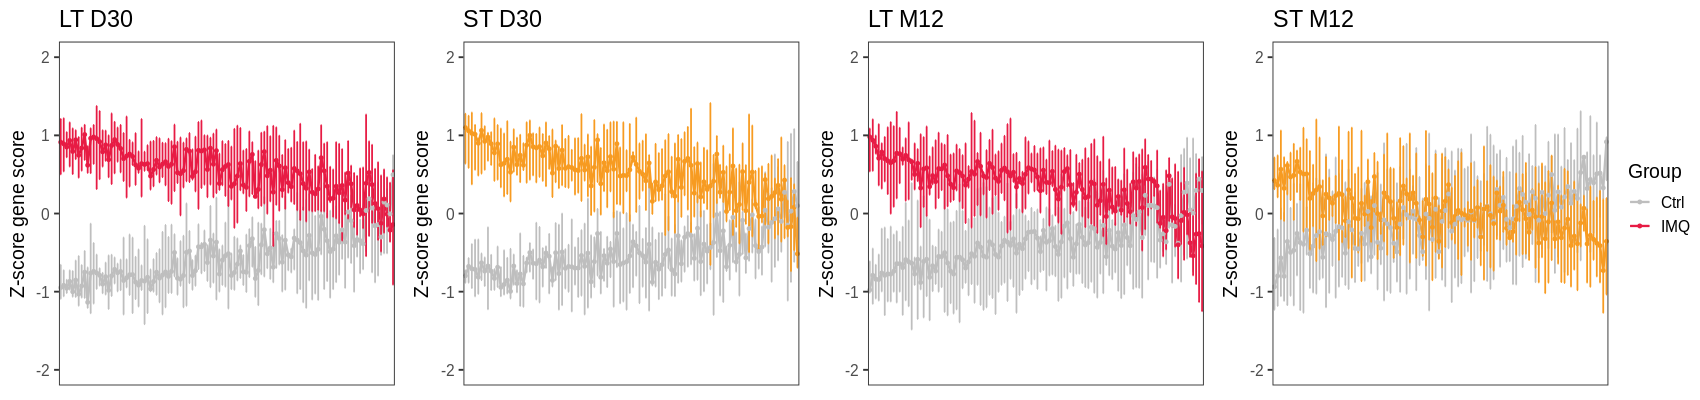

In [19]:
# Function to create plot
create_gene_score_plot <- function(dataset_name, plot_title = dataset_name) {
  # Select the dataset to plot
  plot_data <- all_results[[dataset_name]]
  
  # Determine if it's long-term or short-term
  is_long_term <- grepl("^lt_", dataset_name)
  
  # Set colors based on type
  if (is_long_term) {
    color_imq <- "#e71b44"  # Long-term IMQ
  } else {
    color_imq <- "#f79b21"  # Short-term IMQ
  }
  color_ctrl <- "grey"
  
  # Calculate median per gene and group, then compute delta
  gene_order_by_delta <- plot_data %>%
    group_by(gene, group) %>%
    summarise(median_val = median(value, na.rm = TRUE), .groups = "drop") %>%
    tidyr::pivot_wider(names_from = group, values_from = median_val) %>%
    mutate(delta = IMQ - Ctrl) %>%
    arrange(desc(delta)) %>%
    pull(gene)
  
  # Apply ordering to the dataframe
  plot_df2 <- plot_data %>%
    mutate(gene = factor(gene, levels = gene_order_by_delta))
  
  # Calculate statistics for plotting
  plot_stats <- plot_df2 %>%
    group_by(gene, group) %>%
    summarise(
      median = median(value, na.rm = TRUE),
      q25 = quantile(value, 0.25, na.rm = TRUE),
      q75 = quantile(value, 0.75, na.rm = TRUE),
      .groups = "drop"
    )
  
  # Plot
  p <- ggplot(plot_stats, aes(x = gene, y = median, color = group, group = group)) +
    geom_line(linewidth = 0.8) +
    geom_errorbar(aes(ymin = q25, ymax = q75), width = 0.3, linewidth = 0.6) +
    geom_point(size = 1) +
    scale_color_manual(values = c("IMQ" = color_imq, "Ctrl" = color_ctrl)) +
    labs(x = NULL, y = "Z-score gene score", color = "Group", title = plot_title) +
    theme_bw(base_size = 14) +
    theme(
      axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      panel.grid.minor = element_blank(),
      panel.grid.major = element_blank()
    ) + scale_y_continuous(limits = c(-2, 2))
  
  return(p)
}

p1 <- create_gene_score_plot("lt_d30", "LT D30")
p2 <- create_gene_score_plot("st_d30", "ST D30")
p3 <- create_gene_score_plot("lt_m12", "LT M12")
p4 <- create_gene_score_plot("st_m12", "ST M12")

p_all <- ggarrange( p1, p2, p3, p4, ncol = 4, nrow = 1, common.legend = TRUE, legend = "right")
options(repr.plot.width = 17, repr.plot.height = 4, repr.plot.res = 100)

p_all